# MIL-based span localization for inappropriateness

This notebook evaluates Multiple Instance Learning (MIL) as a weakly supervised span localization approach.

Unlike post-hoc methods such as Integrated Gradients or SHAP, MIL trains a new model. Each argument is treated as a bag and automatically generated candidate spans are treated as latent instances. The model assigns a score to each candidate span and aggregates the strongest span scores into an argument-level prediction.

To make the results comparable to post-hoc attribution methods, the selected MIL spans are evaluated with the same perturbation protocol:

1. Select top-ranked MIL spans.
2. Mask the selected spans in the original argument.
3. Run the Ziegenbein document-level classifier on the masked text.
4. Measure the probability drop for the inappropriate class.

Hyperparameters are selected on the validation split and the final configuration is then applied to train, validation, and test.

In [1]:
import sys
import os
import re
import gc
import json
import math
import time
import html
import random
import unicodedata
from pathlib import Path
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    pipeline,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

from tqdm.auto import tqdm
from IPython.display import HTML, display

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits
from src.utils import (
    highlight_spans,
    mask_spans_in_text,
    predict_with_pipeline,
    trim_char_span,
)

In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Classifier labels
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Device settings
DEVICE = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# General classifier inference settings
CLASSIFIER_MAX_LENGTH = 512
CLASSIFIER_BATCH_SIZE = 32
BATCH_SIZE = 16

# MIL input settings
MIL_MAX_LENGTH = 96
MIL_BATCH_SIZE = 1
ENCODER_CHUNK_SIZE = 4
ENCODER_DTYPE = torch.bfloat16

# Training settings
NUM_EPOCHS = 3

# For frozen encoders, warmup is not essential because only the small MIL head is trained.
# If you later set freeze_encoder=False, 0.1 is a reasonable value again.
WARMUP_RATIO = 0.0

WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0

# Separate learning rates for encoder and new MIL head
ENCODER_LR = 5e-6
HEAD_LR = 1e-4
HEAD_LR_FROZEN_ENCODER = 1e-3

# Candidate span settings
MIN_WORDS = 2
MAX_CANDIDATES = 80

# MIL initialization
INITIAL_INSTANCE_PROB = 0.02

# Perturbation settings
MASKING_TOP_N_SPANS = 3
ABLATION_MODE = "mask"

# Refined single-span-length grid.
# Each config now uses exactly one candidate span length.
SINGLE_SPAN_LENGTH_VALUES = [
    5,
    8,
    10,
    12,
    15
]

SPAN_LENGTH_SETS = [
    (span_length,)
    for span_length in SINGLE_SPAN_LENGTH_VALUES
]

# All existing pooling modes.
POOLING_MODES = [
    "topk_noisy_or",
    "topk_mean",
    "max",
]

# For max pooling, top_k is ignored and only top_k=1 is kept later.
TOP_K_VALUES = [
    1,
    3,
    5,
]

STRIDE_VALUES = [
    2,
    4,
]

# Start with frozen encoder for a manageable refined grid.
# Later, only the best 2-3 configs can be rerun with freeze_encoder=False.
FREEZE_ENCODER_VALUES = [
    True,
]

# Optional debug limits. Set to None for full runs.
DEBUG_MAX_TRAIN_BAGS = None
DEBUG_MAX_VAL_BAGS = None

# Best-config selection preferences.
# The main selection is based on perturbation behavior on validation TPs.
MAX_SELECTION_MASKED_TOKEN_RATIO = 0.60

# Bag-level guardrails are intentionally weak.
# They prevent selecting a completely collapsed MIL model,
# but they do not dominate the span-localization objective.
USE_BAG_QUALITY_GUARDRAILS = True
MIN_VAL_ROC_AUC_GUARDRAIL = 0.55
MIN_VAL_STD_PROB_GUARDRAIL = 0.02

# If no config satisfies the strict masking budget, the notebook relaxes it stepwise.
MASK_BUDGET_RELAXATION_STEPS = [
    0.60,
    0.70,
    0.80
]

print("Device:", TORCH_DEVICE)
print("Number of span-length settings:", len(SPAN_LENGTH_SETS))

In [ ]:
RUN_NAME = "mil_span_run_singles"
BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "mil_results" / RUN_NAME
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving results to:", OUTPUT_DIR)

# Load prepared data

In [ ]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

In [7]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=CLASSIFIER_MAX_LENGTH,
)

classifier_tokenizer = pipe.tokenizer
classifier_model = pipe.model
classifier_model.eval()

MASK_TOKEN = (
    classifier_tokenizer.mask_token
    if classifier_tokenizer.mask_token is not None
    else "[MASK]"
)

print("MASK_TOKEN:", MASK_TOKEN)
print("label2id:", classifier_model.config.label2id)
print("id2label:", classifier_model.config.id2label)

MASK_TOKEN: [MASK]
label2id: {'LABEL_0': 0, 'LABEL_1': 1}
id2label: {0: 'LABEL_0', 1: 'LABEL_1'}


## Candidate span generation

MIL needs candidate spans before training.  
Each argument is treated as a bag and the generated spans are treated as latent instances.

In this refined grid, each configuration uses exactly one candidate span length. This makes the influence of span granularity easier to interpret than multi-scale settings such as `(3, 5, 8)` or `(5, 10, 15)`.

The parameter `span_lengths` is still represented as a tuple for compatibility with the existing code, but it contains only one value in this notebook, for example `(5,)`.

The parameter `stride` controls how densely candidate spans are generated. Smaller strides create more overlapping candidates, while larger strides reduce computational cost and produce coarser coverage.

In [ ]:
def whitespace_token_offsets(text):
    """
    Return whitespace-based tokens with character offsets.
    
    This is intentionally simple and stable for character-level span extraction.
    """
    return [
        {
            "word_index": i,
            "text": match.group(),
            "char_start": int(match.start()),
            "char_end": int(match.end()),
        }
        for i, match in enumerate(re.finditer(r"\S+", str(text)))
    ]


def evenly_limit_candidates(candidates, max_candidates):
    """
    Limit candidates while preserving coverage across the full argument.
    
    This avoids keeping only early spans, which would bias localization toward
    the beginning of the argument.
    """
    if max_candidates is None or len(candidates) <= max_candidates:
        return candidates
    
    indices = np.linspace(0, len(candidates) - 1, max_candidates).round().astype(int)
    indices = sorted(set(indices.tolist()))
    return [candidates[i] for i in indices]


def make_candidate_spans(
    text,
    span_lengths=(5, 10, 15),
    stride=4,
    min_words=MIN_WORDS,
    max_candidates=MAX_CANDIDATES,
):
    """
    Create multi-length candidate spans for MIL.
    
    Each candidate span stores:
    - character offsets,
    - whitespace-word offsets,
    - candidate length,
    - text span.
    """
    text = str(text)
    words = whitespace_token_offsets(text)
    
    if len(words) == 0:
        return []
    
    spans = []
    seen = set()
    
    for span_length in span_lengths:
        for word_start_idx in range(0, len(words), stride):
            word_end_exclusive = min(word_start_idx + span_length, len(words))
            window = words[word_start_idx:word_end_exclusive]
            
            if len(window) < min_words:
                continue
            
            char_start = window[0]["char_start"]
            char_end = window[-1]["char_end"]
            char_start, char_end = trim_char_span(text, char_start, char_end)
            
            if char_end <= char_start:
                continue
            
            key = (char_start, char_end)
            if key in seen:
                continue
            
            seen.add(key)
            
            spans.append({
                "span_text": text[char_start:char_end],
                "char_start": int(char_start),
                "char_end": int(char_end),
                "word_start_idx": int(word_start_idx),
                "word_end_idx": int(word_end_exclusive - 1),
                "span_len_words": int(word_end_exclusive - word_start_idx),
                "span_len_chars": int(char_end - char_start),
                "candidate_span_length": int(span_length),
            })
            
            if word_end_exclusive == len(words):
                break
    
    spans = evenly_limit_candidates(spans, max_candidates=max_candidates)
    return spans


In [10]:
class AppropriatenessMILDataset(Dataset):
    """
    Dataset for MIL span localization.
    
    One item corresponds to one argument-level bag.
    Candidate spans are latent instances within the bag.
    """
    def __init__(
        self,
        df,
        span_lengths=(5, 10, 15),
        stride=4,
        label_col=LABEL_COL,
        text_col=TEXT_NORM_COL,
        max_candidates=MAX_CANDIDATES,
    ):
        self.rows = []
        self.span_lengths = tuple(span_lengths)
        self.stride = int(stride)
        
        for _, row in df.iterrows():
            text = str(row[text_col])
            issue = str(row["issue"])
            label = int(row[label_col])
            
            candidates = make_candidate_spans(
                text=text,
                span_lengths=self.span_lengths,
                stride=self.stride,
                max_candidates=max_candidates,
            )
            
            if len(candidates) == 0:
                continue
            
            self.rows.append({
                "global_row_id": int(row["global_row_id"]),
                "post_id": row[ID_COL],
                "split": row["split"],
                "issue": issue,
                "text": text,
                "label": label,
                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "predicted_label_original": row["predicted_label"],
                "predicted_score_original": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),
                "candidates": candidates,
            })
    
    def __len__(self):
        return len(self.rows)
    
    def __getitem__(self, idx):
        return self.rows[idx]

In [11]:
mil_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def mil_collate_fn(batch, max_length=MIL_MAX_LENGTH):
    """
    Flatten all candidate spans in a batch into one list of encoder inputs.
    
    `bag_ids` stores which flattened span belongs to which original argument.
    """
    flat_inputs = []
    bag_ids = []
    span_metadata = []
    labels = []
    
    bag_metadata = []
    
    for bag_idx, item in enumerate(batch):
        labels.append(item["label"])
        
        bag_metadata.append({
            "global_row_id": item["global_row_id"],
            "post_id": item["post_id"],
            "split": item["split"],
            "issue": item["issue"],
            "text": item["text"],
            "label": item["label"],
            "p_inappropriate_original": item["p_inappropriate_original"],
            "predicted_label_original": item["predicted_label_original"],
            "predicted_score_original": item["predicted_score_original"],
            "confusion_type": item["confusion_type"],
            "is_true_positive": item["is_true_positive"],
            "is_false_negative": item["is_false_negative"],
            "is_false_positive": item["is_false_positive"],
            "is_true_negative": item["is_true_negative"],
            "num_candidate_spans": len(item["candidates"]),
        })
        
        for cand in item["candidates"]:
            # The issue is included because relevance-related inappropriateness
            # can be impossible to judge from a span alone.
            model_input = (
                f"Issue: {item['issue']}\n"
                f"Span: {cand['span_text']}"
            )
            
            flat_inputs.append(model_input)
            bag_ids.append(bag_idx)
            span_metadata.append(cand)
    
    encoded = mil_tokenizer(
        flat_inputs,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    
    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "bag_ids": torch.tensor(bag_ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.float),
        "span_metadata": span_metadata,
        "bag_metadata": bag_metadata,
        "num_bags": len(batch),
    }

In [14]:
class MILPoolingModel(nn.Module):
    """
    MIL model with configurable pooling.
    
    Supported pooling modes:
    - topk_noisy_or: bag is positive if at least one of the top-k spans is positive
    - topk_mean: mean logit over top-k spans
    - max: max-pooling over span logits
    """
    def __init__(
        self,
        model_name,
        pooling_mode="topk_noisy_or",
        top_k=5,
        initial_instance_prob=0.02,
        encoder_chunk_size=4,
        encoder_dtype=torch.bfloat16,
        freeze_encoder=True,
    ):
        super().__init__()
        
        if pooling_mode not in {"topk_noisy_or", "topk_mean", "max"}:
            raise ValueError(f"Unknown pooling mode: {pooling_mode}")
        
        self.encoder = AutoModel.from_pretrained(
            model_name,
            torch_dtype=encoder_dtype,
        )
        
        self.freeze_encoder = bool(freeze_encoder)
        
        if self.freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
        else:
            # Useful for memory-saving when fine-tuning.
            self.encoder.gradient_checkpointing_enable()
        
        hidden_size = self.encoder.config.hidden_size
        
        self.instance_classifier = nn.Linear(hidden_size, 1)
        self.pooling_mode = pooling_mode
        self.top_k = int(top_k)
        self.encoder_chunk_size = int(encoder_chunk_size)
        
        initial_bias = math.log(
            initial_instance_prob / (1.0 - initial_instance_prob)
        )
        
        # Small random initialization avoids identical span scores at the beginning.
        nn.init.normal_(self.instance_classifier.weight, mean=0.0, std=0.01)
        nn.init.constant_(self.instance_classifier.bias, initial_bias)
    
    def encode_in_chunks(self, input_ids, attention_mask):
        """
        Encode flattened candidate spans in chunks.
        
        When the encoder is frozen, no gradients are stored for the encoder,
        which substantially speeds up and reduces memory use.
        """
        cls_outputs = []
        
        context = torch.no_grad() if self.freeze_encoder else torch.enable_grad()
        
        with context:
            for start in range(0, input_ids.size(0), self.encoder_chunk_size):
                end = min(start + self.encoder_chunk_size, input_ids.size(0))
                
                outputs = self.encoder(
                    input_ids=input_ids[start:end],
                    attention_mask=attention_mask[start:end],
                    output_hidden_states=False,
                    output_attentions=False,
                    return_dict=True,
                )
                
                cls_outputs.append(outputs.last_hidden_state[:, 0].float())
        
        return torch.cat(cls_outputs, dim=0)
    
    def pool_logits(self, logits):
        """
        Aggregate instance logits into one bag logit.
        
        The output is a logit so that BCEWithLogitsLoss can be used.
        """
        if logits.numel() == 0:
            raise ValueError("Cannot pool an empty set of instance logits.")
        
        if self.pooling_mode == "max":
            return logits.max()
        
        k = min(self.top_k, logits.numel())
        logits_topk, _ = torch.topk(logits, k=k)
        
        if self.pooling_mode == "topk_mean":
            return logits_topk.mean()
        
        if self.pooling_mode == "topk_noisy_or":
            # Stable version of:
            # p_bag = 1 - product_j(1 - sigmoid(logit_j))
            log_p_negative = torch.sum(torch.nn.functional.logsigmoid(-logits_topk))
            log_p_negative = torch.clamp(log_p_negative, max=-1e-6)
            
            log_p_positive = torch.log(-torch.expm1(log_p_negative))
            bag_logit = log_p_positive - log_p_negative
            return bag_logit
        
        raise ValueError(f"Unknown pooling mode: {self.pooling_mode}")
    
    def forward(self, input_ids, attention_mask, bag_ids, num_bags):
        cls = self.encode_in_chunks(input_ids, attention_mask)
        
        instance_logits = self.instance_classifier(cls).squeeze(-1)
        instance_probs = torch.sigmoid(instance_logits)
        
        bag_logits = []
        bag_probs = []
        
        for bag_idx in range(num_bags):
            logits = instance_logits[bag_ids == bag_idx]
            bag_logit = self.pool_logits(logits)
            bag_prob = torch.sigmoid(bag_logit)
            
            bag_logits.append(bag_logit)
            bag_probs.append(bag_prob)
        
        return {
            "bag_logits": torch.stack(bag_logits),
            "bag_probs": torch.stack(bag_probs),
            "instance_logits": instance_logits,
            "instance_probs": instance_probs,
        }

In [13]:
def make_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset=None,
    batch_size=MIL_BATCH_SIZE,
):
    """Create MIL dataloaders."""
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=mil_collate_fn,
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=mil_collate_fn,
    )
    
    if test_dataset is None:
        return train_loader, val_loader
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=mil_collate_fn,
    )
    
    return train_loader, val_loader, test_loader


def evaluate_bag_level(model, dataloader, threshold=0.5):
    """
    Evaluate MIL bag-level predictions against document-level labels.
    
    These metrics do not evaluate span correctness directly.
    """
    model.eval()
    
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in dataloader:
            outputs = model(
                input_ids=batch["input_ids"].to(TORCH_DEVICE),
                attention_mask=batch["attention_mask"].to(TORCH_DEVICE),
                bag_ids=batch["bag_ids"].to(TORCH_DEVICE),
                num_bags=batch["num_bags"],
            )
            
            all_labels.extend(batch["labels"].cpu().numpy().tolist())
            all_probs.extend(outputs["bag_probs"].detach().cpu().numpy().tolist())
    
    all_labels = np.array(all_labels, dtype=int)
    all_probs = np.array(all_probs, dtype=float)
    preds = (all_probs >= threshold).astype(int)
    
    metrics = {
        "accuracy": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
    }
    
    if len(np.unique(all_labels)) > 1:
        metrics["roc_auc"] = roc_auc_score(all_labels, all_probs)
    else:
        metrics["roc_auc"] = np.nan
    
    metrics["mean_predicted_probability"] = float(np.mean(all_probs))
    metrics["std_predicted_probability"] = float(np.std(all_probs))
    metrics["positive_prediction_rate"] = float(np.mean(preds))
    
    return metrics

In [14]:
def build_optimizer(model, freeze_encoder):
    """Build optimizer with separate learning rates for encoder and MIL head."""
    if freeze_encoder:
        return torch.optim.AdamW(
            model.instance_classifier.parameters(),
            lr=HEAD_LR_FROZEN_ENCODER,
            weight_decay=WEIGHT_DECAY,
        )
    
    return torch.optim.AdamW(
        [
            {"params": model.encoder.parameters(), "lr": ENCODER_LR},
            {"params": model.instance_classifier.parameters(), "lr": HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )


def train_one_mil_model(
    config,
    train_dataset,
    val_dataset,
    output_dir,
):
    """
    Train one MIL configuration and return the trained model plus logs.
    
    Hyperparameters are supplied through config.
    """
    train_loader, val_loader = make_dataloaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=MIL_BATCH_SIZE,
    )
    
    model = MILPoolingModel(
        model_name=MODEL_NAME,
        pooling_mode=config["pooling_mode"],
        top_k=config["top_k"],
        initial_instance_prob=INITIAL_INSTANCE_PROB,
        encoder_chunk_size=ENCODER_CHUNK_SIZE,
        encoder_dtype=ENCODER_DTYPE,
        freeze_encoder=config["freeze_encoder"],
    ).to(TORCH_DEVICE)
    
    optimizer = build_optimizer(model, freeze_encoder=config["freeze_encoder"])
    
    num_training_steps = NUM_EPOCHS * len(train_loader)
    num_warmup_steps = int(WARMUP_RATIO * num_training_steps)
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
    )
    
    criterion = nn.BCEWithLogitsLoss()
    training_history = []
    best_val_f1 = -1.0
    best_state_dict = None
    
    start_time = time.time()
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_start = time.time()
        total_loss = 0.0
        
        for step, batch in enumerate(train_loader):
            optimizer.zero_grad(set_to_none=True)
            
            outputs = model(
                input_ids=batch["input_ids"].to(TORCH_DEVICE),
                attention_mask=batch["attention_mask"].to(TORCH_DEVICE),
                bag_ids=batch["bag_ids"].to(TORCH_DEVICE),
                num_bags=batch["num_bags"],
            )
            
            labels = batch["labels"].to(TORCH_DEVICE).float()
            loss = criterion(outputs["bag_logits"], labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += float(loss.item())
            
            if step % 50 == 0:
                print(
                    f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
                    f"Step {step}/{len(train_loader)} | "
                    f"Loss {loss.item():.4f}"
                )
        
        avg_loss = total_loss / max(len(train_loader), 1)
        val_metrics = evaluate_bag_level(model, val_loader)
        epoch_time = (time.time() - epoch_start) / 60
        
        row = {
            "epoch": epoch + 1,
            "train_loss": avg_loss,
            "epoch_time_minutes": epoch_time,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        
        training_history.append(row)
        
        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} finished | "
            f"loss={avg_loss:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_auc={val_metrics['roc_auc']:.4f} | "
            f"time={epoch_time:.2f} min"
        )
        
        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
    
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    
    total_time = (time.time() - start_time) / 60
    
    train_metrics = evaluate_bag_level(model, train_loader)
    val_metrics = evaluate_bag_level(model, val_loader)
    
    result = {
        **config,
        "train_time_minutes": total_time,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    
    history_df = pd.DataFrame(training_history)
    
    return model, result, history_df

In [15]:
def collect_mil_outputs(model, dataset, config, threshold=0.5):
    """
    Collect bag-level predictions and span-level scores from a trained MIL model.
    
    Returns:
    - argument_df: one row per argument
    - span_df: one row per candidate span
    """
    model.eval()
    
    argument_rows = []
    span_rows = []
    
    for item_idx, item in enumerate(tqdm(dataset, desc="Collecting MIL outputs")):
        batch = mil_collate_fn([item])
        
        with torch.no_grad():
            outputs = model(
                input_ids=batch["input_ids"].to(TORCH_DEVICE),
                attention_mask=batch["attention_mask"].to(TORCH_DEVICE),
                bag_ids=batch["bag_ids"].to(TORCH_DEVICE),
                num_bags=batch["num_bags"],
            )
        
        bag_prob = float(outputs["bag_probs"].detach().cpu().item())
        pred_label = int(bag_prob >= threshold)
        instance_probs = outputs["instance_probs"].detach().cpu().numpy()
        instance_logits = outputs["instance_logits"].detach().cpu().numpy()
        
        meta = batch["bag_metadata"][0]
        
        argument_rows.append({
            **meta,
            "mil_probability": bag_prob,
            "mil_predicted_label": pred_label,
            "mil_correct": int(pred_label == meta["label"]),
            "mil_confusion_type": (
                "TP" if meta["label"] == 1 and pred_label == 1 else
                "FN" if meta["label"] == 1 and pred_label == 0 else
                "FP" if meta["label"] == 0 and pred_label == 1 else
                "TN"
            ),
            **config,
        })
        
        for prob, logit, span in zip(
            instance_probs,
            instance_logits,
            batch["span_metadata"],
        ):
            span_rows.append({
                "global_row_id": meta["global_row_id"],
                "post_id": meta["post_id"],
                "split": meta["split"],
                "issue": meta["issue"],
                "label": meta["label"],
                "confusion_type": meta["confusion_type"],
                "mil_probability": bag_prob,
                "mil_predicted_label": pred_label,
                "span_score": float(prob),
                "span_logit": float(logit),
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "word_start_idx": span["word_start_idx"],
                "word_end_idx": span["word_end_idx"],
                "span_len_words": span["span_len_words"],
                "span_len_chars": span["span_len_chars"],
                "candidate_span_length": span["candidate_span_length"],
                "text": meta["text"],
                **config,
            })
    
    argument_df = pd.DataFrame(argument_rows)
    span_df = pd.DataFrame(span_rows)
    
    span_df["span_rank"] = (
        span_df
        .groupby(["global_row_id"])["span_score"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    
    return argument_df, span_df

In [ ]:
def merge_char_spans(span_records, text=None):
    """
    Merge overlapping or directly adjacent character spans.

    This ensures that overlapping MIL spans are only counted and masked once.
    """
    if not span_records:
        return []

    text_len = len(text) if text is not None else None

    spans = []

    for span in span_records:
        start = int(span["char_start"])
        end = int(span["char_end"])

        if text_len is not None:
            start = max(0, min(start, text_len))
            end = max(0, min(end, text_len))

        if end <= start:
            continue

        spans.append({
            "char_start": start,
            "char_end": end,
        })

    if not spans:
        return []

    spans = sorted(spans, key=lambda x: (x["char_start"], x["char_end"]))

    merged = [dict(spans[0])]

    for span in spans[1:]:
        last = merged[-1]

        if span["char_start"] <= last["char_end"]:
            last["char_end"] = max(last["char_end"], span["char_end"])
        else:
            merged.append(dict(span))

    if text is not None:
        for span in merged:
            span["span_text"] = text[span["char_start"]:span["char_end"]]
            span["span_len_chars"] = span["char_end"] - span["char_start"]

    return merged


def mask_spans_in_text(text, spans, mask_token=MASK_TOKEN):
    """
    Mask merged character spans in a text.

    The same merged spans are later used for token counting, so masking and
    masked_token_ratio refer to the same text regions.
    """
    text = str(text)

    if not spans:
        return text

    merged_spans = merge_char_spans(spans, text=text)

    if not merged_spans:
        return text

    parts = []
    last_end = 0

    for span in merged_spans:
        start = int(span["char_start"])
        end = int(span["char_end"])

        parts.append(text[last_end:start])
        parts.append(mask_token)
        last_end = end

    parts.append(text[last_end:])

    return "".join(parts)


def count_model_tokens_in_char_spans(
    text,
    char_spans,
    tokenizer,
    max_length=CLASSIFIER_MAX_LENGTH,
):
    """
    Count unique classifier tokens that overlap with selected character spans.

    The ratio is computed as:
        unique masked model tokens / all model tokens seen by the classifier

    Therefore, masked_token_ratio cannot exceed 1.
    """
    text = str(text)
    merged_spans = merge_char_spans(char_spans, text=text)

    encoded = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=False,
        truncation=True,
        max_length=max_length,
    )

    offsets = encoded["offset_mapping"]

    valid_token_offsets = [
        (idx, int(start), int(end))
        for idx, (start, end) in enumerate(offsets)
        if int(end) > int(start)
    ]

    n_model_tokens = len(valid_token_offsets)

    if n_model_tokens == 0:
        return 0, 0, np.nan, []

    masked_token_indices = []

    for token_idx, token_start, token_end in valid_token_offsets:
        overlaps_selected_span = any(
            token_start < int(span["char_end"]) and token_end > int(span["char_start"])
            for span in merged_spans
        )

        if overlaps_selected_span:
            masked_token_indices.append(int(token_idx))

    masked_token_indices = sorted(set(masked_token_indices))
    total_masked_tokens = len(masked_token_indices)
    masked_token_ratio = total_masked_tokens / n_model_tokens

    return (
        int(total_masked_tokens),
        int(n_model_tokens),
        float(masked_token_ratio),
        masked_token_indices,
    )


def get_unique_masked_word_indices(span_records):
    """
    Count unique word indices covered by selected spans.

    This keeps masked_word_ratio as an additional diagnostic, but the main
    comparison metric should be masked_token_ratio.
    """
    masked_word_indices = set()

    for span in span_records:
        start = int(span["word_start_idx"])
        end = int(span["word_end_idx"])

        if end < start:
            continue

        masked_word_indices.update(range(start, end + 1))

    return sorted(masked_word_indices)


def predict_masked_texts(texts, batch_size=CLASSIFIER_BATCH_SIZE):
    """Predict inappropriate probabilities for masked texts."""
    pred_df = predict_with_pipeline(texts=texts, classifier=pipe, batch_size=batch_size)
    return pred_df["p_inappropriate_original"].tolist()


def add_mil_perturbation_scores(
    argument_df,
    span_df,
    top_n_spans=MASKING_TOP_N_SPANS,
    mask_token=MASK_TOKEN,
):
    """
    Select top-N MIL spans per argument, mask them, and score the masked text.

    Overlapping selected spans are merged before masking and before counting
    model tokens. This prevents masked_token_ratio values greater than 1.
    """
    argument_df = argument_df.copy()
    span_df = span_df.copy()

    top_span_df = (
        span_df
        .sort_values(["global_row_id", "span_score"], ascending=[True, False])
        .groupby("global_row_id")
        .head(top_n_spans)
        .copy()
    )

    masked_texts = []

    selected_spans_json = []
    selected_span_texts = []
    selected_char_starts = []
    selected_char_ends = []
    selected_word_starts = []
    selected_word_ends = []

    merged_masked_spans_json = []
    selected_unique_word_indices_json = []
    selected_token_indices_json = []

    total_masked_chars = []
    total_masked_words = []
    total_masked_tokens = []
    n_model_tokens = []
    masked_token_ratios = []

    n_selected_spans = []

    for _, row in argument_df.iterrows():
        gid = row["global_row_id"]
        text = str(row["text"])

        spans = top_span_df[top_span_df["global_row_id"] == gid].copy()

        span_records = []

        for _, span in spans.iterrows():
            span_records.append({
                "span_text": span["span_text"],
                "char_start": int(span["char_start"]),
                "char_end": int(span["char_end"]),
                "word_start_idx": int(span["word_start_idx"]),
                "word_end_idx": int(span["word_end_idx"]),
                "span_len_words": int(span["span_len_words"]),
                "span_len_chars": int(span["span_len_chars"]),
                "span_score": float(span["span_score"]),
                "span_rank": int(span["span_rank"]),
                "candidate_span_length": int(span["candidate_span_length"]),
            })

        merged_char_spans = merge_char_spans(span_records, text=text)

        masked_text = mask_spans_in_text(
            text=text,
            spans=merged_char_spans,
            mask_token=mask_token,
        )

        unique_masked_word_indices = get_unique_masked_word_indices(span_records)

        (
            total_masked_tokens_i,
            n_model_tokens_i,
            masked_token_ratio_i,
            masked_token_indices_i,
        ) = count_model_tokens_in_char_spans(
            text=text,
            char_spans=merged_char_spans,
            tokenizer=classifier_tokenizer,
            max_length=CLASSIFIER_MAX_LENGTH,
        )

        masked_texts.append(masked_text)

        selected_spans_json.append(json.dumps(span_records, ensure_ascii=False))
        selected_span_texts.append([s["span_text"] for s in span_records])
        selected_char_starts.append([s["char_start"] for s in span_records])
        selected_char_ends.append([s["char_end"] for s in span_records])
        selected_word_starts.append([s["word_start_idx"] for s in span_records])
        selected_word_ends.append([s["word_end_idx"] for s in span_records])

        merged_masked_spans_json.append(
            json.dumps(merged_char_spans, ensure_ascii=False)
        )

        selected_unique_word_indices_json.append(
            json.dumps(unique_masked_word_indices, ensure_ascii=False)
        )

        selected_token_indices_json.append(
            json.dumps(masked_token_indices_i, ensure_ascii=False)
        )

        total_masked_chars.append(
            sum(
                int(span["char_end"]) - int(span["char_start"])
                for span in merged_char_spans
            )
        )

        total_masked_words.append(len(unique_masked_word_indices))
        total_masked_tokens.append(total_masked_tokens_i)
        n_model_tokens.append(n_model_tokens_i)
        masked_token_ratios.append(masked_token_ratio_i)

        n_selected_spans.append(len(span_records))

    p_masked = predict_masked_texts(masked_texts)

    argument_df["attribution_method"] = "mil"
    argument_df["ablation_mode"] = ABLATION_MODE
    argument_df["top_n_masked_spans"] = top_n_spans

    argument_df["masked_text"] = masked_texts
    argument_df["p_inappropriate_masked"] = p_masked

    argument_df["prob_drop"] = (
        argument_df["p_inappropriate_original"] -
        argument_df["p_inappropriate_masked"]
    )

    argument_df["selected_spans_json"] = selected_spans_json
    argument_df["selected_span_texts"] = selected_span_texts
    argument_df["selected_span_char_start_indices"] = selected_char_starts
    argument_df["selected_span_char_end_indices"] = selected_char_ends
    argument_df["selected_span_word_start_indices"] = selected_word_starts
    argument_df["selected_span_word_end_indices"] = selected_word_ends

    argument_df["merged_masked_spans_json"] = merged_masked_spans_json
    argument_df["selected_unique_word_indices_json"] = selected_unique_word_indices_json
    argument_df["selected_token_indices_json"] = selected_token_indices_json

    argument_df["n_selected_spans"] = n_selected_spans

    argument_df["total_masked_chars"] = total_masked_chars
    argument_df["total_masked_words"] = total_masked_words
    argument_df["total_masked_tokens"] = total_masked_tokens
    argument_df["n_model_tokens"] = n_model_tokens

    argument_df["n_words"] = argument_df["text"].apply(
        lambda x: len(whitespace_token_offsets(x))
    )

    argument_df["masked_word_ratio"] = (
        argument_df["total_masked_words"] /
        argument_df["n_words"].replace(0, np.nan)
    )

    argument_df["masked_token_ratio"] = masked_token_ratios

    if argument_df["masked_token_ratio"].dropna().gt(1.0 + 1e-9).any():
        problematic = argument_df[
            argument_df["masked_token_ratio"] > 1.0 + 1e-9
        ][
            [
                "global_row_id",
                "n_model_tokens",
                "total_masked_tokens",
                "masked_token_ratio",
                "selected_spans_json",
                "merged_masked_spans_json",
            ]
        ]

        raise ValueError(
            "masked_token_ratio > 1 detected. "
            "This should not happen after unique token counting.\n"
            f"{problematic.head()}"
        )

    return argument_df, top_span_df

In [ ]:
def build_config_id(config):
    """Create a readable config ID for filenames and tables."""
    span_label = "-".join(map(str, config["span_lengths"]))
    return (
        f"pool={config['pooling_mode']}"
        f"__topk={config['top_k']}"
        f"__spans={span_label}"
        f"__stride={config['stride']}"
        f"__freeze={config['freeze_encoder']}"
    )


def subset_dataset(dataset, max_items):
    """Optionally limit a dataset for debugging."""
    if max_items is None:
        return dataset
    
    dataset.rows = dataset.rows[:max_items]
    return dataset


def run_single_validation_config(config):
    """
    Train and evaluate one MIL configuration.
    
    The model is trained on train and evaluated on validation.
    Perturbation is computed on validation true positives from the original
    Ziegenbein classifier to stay comparable with IG/SHAP.
    """
    config = dict(config)
    config["config_id"] = build_config_id(config)
    
    print("\n" + "=" * 100)
    print("Running config:", config["config_id"], flush=True)
    print("=" * 100)
    
    config_dir = OUTPUT_DIR / "validation_grid" / config["config_id"]
    config_dir.mkdir(parents=True, exist_ok=True)
    
    train_dataset = AppropriatenessMILDataset(
        train_df,
        span_lengths=config["span_lengths"],
        stride=config["stride"],
    )
    
    val_dataset = AppropriatenessMILDataset(
        val_df,
        span_lengths=config["span_lengths"],
        stride=config["stride"],
    )
    
    train_dataset = subset_dataset(train_dataset, DEBUG_MAX_TRAIN_BAGS)
    val_dataset = subset_dataset(val_dataset, DEBUG_MAX_VAL_BAGS)
    
    model, metrics_row, history_df = train_one_mil_model(
        config=config,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        output_dir=config_dir,
    )
    
    val_argument_df, val_span_df = collect_mil_outputs(
        model=model,
        dataset=val_dataset,
        config=config,
    )
    
    # Perturbation on validation TPs based on the original Ziegenbein classifier.
    val_tp_argument_df = val_argument_df[
        val_argument_df["confusion_type"] == "TP"
    ].copy()
    
    val_tp_span_df = val_span_df[
        val_span_df["global_row_id"].isin(val_tp_argument_df["global_row_id"])
    ].copy()
    
    if len(val_tp_argument_df) > 0:
        val_tp_argument_df, val_top_span_df = add_mil_perturbation_scores(
            argument_df=val_tp_argument_df,
            span_df=val_tp_span_df,
            top_n_spans=MASKING_TOP_N_SPANS,
        )
        
        perturbation_summary = {
            "val_tp_n_arguments": int(val_tp_argument_df["global_row_id"].nunique()),
            "val_tp_mean_prob_drop": float(val_tp_argument_df["prob_drop"].mean()),
            "val_tp_median_prob_drop": float(val_tp_argument_df["prob_drop"].median()),
            "val_tp_positive_drop_rate": float((val_tp_argument_df["prob_drop"] > 0).mean()),
            "val_tp_strong_drop_rate_001": float((val_tp_argument_df["prob_drop"] > 0.01).mean()),
            "val_tp_strong_drop_rate_005": float((val_tp_argument_df["prob_drop"] > 0.05).mean()),
            "val_tp_mean_masked_word_ratio": float(val_tp_argument_df["masked_word_ratio"].mean()),
            "val_tp_mean_total_masked_words": float(val_tp_argument_df["total_masked_words"].mean()),

            "val_tp_mean_masked_token_ratio": float(val_tp_argument_df["masked_token_ratio"].mean()),
            "val_tp_mean_total_masked_tokens": float(val_tp_argument_df["total_masked_tokens"].mean()),
            "val_tp_mean_n_model_tokens": float(val_tp_argument_df["n_model_tokens"].mean()),
        }
    else:
        val_top_span_df = pd.DataFrame()
        perturbation_summary = {
            "val_tp_n_arguments": 0,
            "val_tp_mean_prob_drop": np.nan,
            "val_tp_median_prob_drop": np.nan,
            "val_tp_positive_drop_rate": np.nan,
            "val_tp_strong_drop_rate_001": np.nan,
            "val_tp_strong_drop_rate_005": np.nan,
            "val_tp_mean_masked_word_ratio": np.nan,
            "val_tp_mean_total_masked_words": np.nan,

            "val_tp_mean_masked_token_ratio": np.nan,
            "val_tp_mean_total_masked_tokens": np.nan,
            "val_tp_mean_n_model_tokens": np.nan,
        }
    
    final_row = {
        **metrics_row,
        **perturbation_summary,
    }
    
    history_df.to_csv(config_dir / "training_history.csv", index=False)
    val_argument_df.to_csv(config_dir / "validation_argument_predictions.csv", index=False)
    val_span_df.to_csv(config_dir / "validation_span_scores.csv", index=False)
    val_tp_argument_df.to_csv(config_dir / "validation_tp_perturbation.csv", index=False)
    val_top_span_df.to_csv(config_dir / "validation_tp_top_spans.csv", index=False)
    
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": config,
            "metrics": final_row,
        },
        config_dir / "model_checkpoint.pt",
    )
    
    # Free memory between configs.
    model_cpu_state = {
        k: v.cpu()
        for k, v in model.state_dict().items()
    }
    
    del model
    gc.collect()
    torch.cuda.empty_cache()
    
    return final_row, model_cpu_state

In [18]:
validation_grid = []

for pooling_mode, span_lengths, stride, freeze_encoder in product(
    POOLING_MODES,
    SPAN_LENGTH_SETS,
    STRIDE_VALUES,
    FREEZE_ENCODER_VALUES,
):
    for top_k in TOP_K_VALUES:
        # max pooling does not use top_k. Keep only one version to avoid duplicates.
        if pooling_mode == "max" and top_k != 1:
            continue
        
        validation_grid.append({
            "pooling_mode": pooling_mode,
            "top_k": int(top_k),
            "span_lengths": tuple(span_lengths),
            "span_lengths_label": "-".join(map(str, span_lengths)),
            "span_length_single": int(span_lengths[0]),
            "stride": int(stride),
            "freeze_encoder": bool(freeze_encoder),
        })

print("Number of configs:", len(validation_grid))
display(pd.DataFrame(validation_grid))

Number of configs: 70


,pooling_mode,top_k,span_lengths,span_lengths_label,span_length_single,stride,freeze_encoder
0,topk_noisy_or,1,"(5,)",5,5,2,True
1,topk_noisy_or,3,"(5,)",5,5,2,True
2,topk_noisy_or,5,"(5,)",5,5,2,True
3,topk_noisy_or,1,"(5,)",5,5,4,True
4,topk_noisy_or,3,"(5,)",5,5,4,True
...,...,...,...,...,...,...,...
65,max,1,"(10,)",10,10,4,True
66,max,1,"(12,)",12,12,2,True
67,max,1,"(12,)",12,12,4,True
68,max,1,"(15,)",15,15,2,True


In [ ]:
grid_results = []
best_state_by_config = {}

for config in validation_grid:
    result_row, model_state = run_single_validation_config(config)
    grid_results.append(result_row)
    best_state_by_config[result_row["config_id"]] = model_state
    
    grid_df_partial = pd.DataFrame(grid_results)
    grid_df_partial.to_csv(
        OUTPUT_DIR / "mil_validation_grid_partial_results.csv",
        index=False,
    )

val_config_summary = pd.DataFrame(grid_results)

val_config_summary.to_csv(
    OUTPUT_DIR / "mil_validation_config_summary.csv",
    index=False,
)

display(val_config_summary)

In [5]:
# If necessary load config summary, so evaluation can be resumed without re-running all configs.
val_config_summary = pd.read_csv(OUTPUT_DIR / "mil_validation_config_summary.csv")
display(val_config_summary)

,pooling_mode,top_k,span_lengths,span_lengths_label,span_length_single,stride,freeze_encoder,config_id,train_time_minutes,train_accuracy,...,val_tp_mean_prob_drop,val_tp_median_prob_drop,val_tp_positive_drop_rate,val_tp_strong_drop_rate_001,val_tp_strong_drop_rate_005,val_tp_mean_masked_word_ratio,val_tp_mean_total_masked_words,val_tp_mean_masked_token_ratio,val_tp_mean_total_masked_tokens,val_tp_mean_n_model_tokens
0,topk_noisy_or,1,"(5,)",5,5,2,True,pool=topk_noisy_or__topk=1__spans=5__stride=2_...,23.295736,0.707763,...,0.068082,0.000141,0.579545,0.204545,0.136364,0.268843,12.488636,0.279292,16.454545,92.375
1,topk_noisy_or,3,"(5,)",5,5,2,True,pool=topk_noisy_or__topk=3__spans=5__stride=2_...,23.328762,0.689498,...,0.089237,0.000338,0.625000,0.227273,0.170455,0.272332,12.545455,0.281921,16.375000,92.375
2,topk_noisy_or,5,"(5,)",5,5,2,True,pool=topk_noisy_or__topk=5__spans=5__stride=2_...,23.318593,0.696021,...,0.082046,0.000203,0.625000,0.204545,0.170455,0.270249,12.443182,0.280335,16.250000,92.375
3,topk_noisy_or,1,"(5,)",5,5,4,True,pool=topk_noisy_or__topk=1__spans=5__stride=4_...,12.756056,0.687541,...,0.082017,0.000172,0.602273,0.204545,0.170455,0.308228,13.920455,0.322260,18.068182,92.375
4,topk_noisy_or,3,"(5,)",5,5,4,True,pool=topk_noisy_or__topk=3__spans=5__stride=4_...,12.770072,0.711024,...,0.069206,0.000233,0.647727,0.170455,0.147727,0.306991,13.886364,0.322137,18.147727,92.375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,max,1,"(10,)",10,10,4,True,pool=max__topk=1__spans=10__stride=4__freeze=True,12.141292,0.744292,...,0.126009,0.000899,0.670455,0.352273,0.238636,0.447337,22.295455,0.456916,28.136364,92.375
66,max,1,"(12,)",12,12,2,True,pool=max__topk=1__spans=12__stride=2__freeze=True,21.745995,0.761252,...,0.142477,0.000609,0.659091,0.352273,0.261364,0.440214,22.340909,0.448284,28.000000,92.375
67,max,1,"(12,)",12,12,4,True,pool=max__topk=1__spans=12__stride=4__freeze=True,11.875334,0.765166,...,0.173775,0.001102,0.659091,0.352273,0.306818,0.484325,25.159091,0.491251,31.500000,92.375
68,max,1,"(15,)",15,15,2,True,pool=max__topk=1__spans=15__stride=2__freeze=True,20.956230,0.769080,...,0.141335,0.000571,0.625000,0.318182,0.272727,0.461008,23.181818,0.462751,28.579545,92.375


In [7]:
val_config_summary = val_config_summary.copy()

# Efficiency-style diagnostic.
# This is not the main criterion because it can over-favor tiny spans with tiny drops,
# but it is useful for interpretation.
val_config_summary["val_tp_drop_per_masked_token_ratio"] = (
    val_config_summary["val_tp_mean_prob_drop"] /
    val_config_summary["val_tp_mean_masked_token_ratio"].replace(0, np.nan)
)

# Rank-based scores avoid scale problems.
# Higher rank percentile means better relative performance.
val_config_summary["rank_prob_drop"] = (
    val_config_summary["val_tp_mean_prob_drop"]
    .fillna(-np.inf)
    .rank(pct=True)
)

val_config_summary["rank_positive_drop_rate"] = (
    val_config_summary["val_tp_positive_drop_rate"]
    .fillna(-np.inf)
    .rank(pct=True)
)

# Lower masked token ratio is better.
val_config_summary["rank_mask_efficiency"] = (
    (-val_config_summary["val_tp_mean_masked_token_ratio"].fillna(np.inf))
    .rank(pct=True)
)

# This selection score reflects the actual span-localization objective:
# high probability drop, high positive drop rate, and low masked token ratio.
val_config_summary["selection_score"] = (
    0.4 * val_config_summary["rank_prob_drop"]
    + 0.4 * val_config_summary["rank_positive_drop_rate"]
    + 0.2 * val_config_summary["rank_mask_efficiency"]
)

def select_best_config(
    df,
    mask_budget_steps=MASK_BUDGET_RELAXATION_STEPS,
    use_bag_guardrails=USE_BAG_QUALITY_GUARDRAILS,
):
    """
    Select the final MIL configuration on validation only.
    
    Main objective:
    - high mean probability drop on validation TPs
    - high positive drop rate on validation TPs
    - low masked token ratio
    
    Bag-level metrics are used only as weak guardrails to avoid selecting
    a collapsed MIL model.
    """
    df = df.copy()
    
    # Basic validity filters.
    base = df[
        df["val_tp_mean_prob_drop"].notna() &
        df["val_tp_positive_drop_rate"].notna() &
        df["val_tp_mean_masked_token_ratio"].notna() &
        (df["val_tp_n_arguments"] > 0)
    ].copy()
    
    if use_bag_guardrails:
        guarded = base[
            (base["val_roc_auc"].fillna(0) >= MIN_VAL_ROC_AUC_GUARDRAIL) &
            (base["val_std_predicted_probability"].fillna(0) >= MIN_VAL_STD_PROB_GUARDRAIL)
        ].copy()
        
        if len(guarded) > 0:
            base = guarded
        else:
            print(
                "Warning: No config satisfies the bag-level guardrails. "
                "Falling back to perturbation-only selection."
            )
    
    selected_budget = None
    candidates = pd.DataFrame()
    
    for budget in mask_budget_steps:
        candidates = base[
            base["val_tp_mean_masked_token_ratio"] <= budget
        ].copy()
        
        if len(candidates) > 0:
            selected_budget = budget
            break
    
    if len(candidates) == 0:
        print(
            "Warning: No config satisfies any masking budget. "
            "Selecting from all valid configs."
        )
        candidates = base.copy()
        selected_budget = None
    
    candidates = candidates.sort_values(
        [
            "selection_score",
            "val_tp_mean_prob_drop",
            "val_tp_positive_drop_rate",
            "val_tp_mean_masked_token_ratio",
            "val_roc_auc",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            False,
        ],
    )
    
    best = candidates.iloc[0].to_dict()
    
    return best, candidates, selected_budget


BEST_CONFIG, candidate_configs, SELECTED_MASK_BUDGET = select_best_config(
    val_config_summary
)

print("Selected mask budget:", SELECTED_MASK_BUDGET)
print("Selected config:")
for key in [
    "config_id",
    "pooling_mode",
    "top_k",
    "span_lengths",
    "span_lengths_label",
    "span_length_single",
    "stride",
    "freeze_encoder",
    "val_tp_mean_prob_drop",
    "val_tp_positive_drop_rate",
    "val_tp_mean_masked_token_ratio",
    "val_tp_drop_per_masked_token_ratio",
    "val_roc_auc",
    "val_f1",
    "selection_score",
]:
    if key in BEST_CONFIG:
        print(f"{key}: {BEST_CONFIG[key]}")

display(
    candidate_configs[
        [
            "config_id",
            "pooling_mode",
            "top_k",
            "span_lengths_label",
            "span_length_single",
            "stride",
            "freeze_encoder",
            "val_tp_n_arguments",
            "val_tp_mean_prob_drop",
            "val_tp_positive_drop_rate",
            "val_tp_strong_drop_rate_001",
            "val_tp_strong_drop_rate_005",
            "val_tp_mean_masked_token_ratio",
            "val_tp_drop_per_masked_token_ratio",
            "val_roc_auc",
            "val_f1",
            "selection_score",
        ]
    ].head(20)
)

val_config_summary.to_csv(
    OUTPUT_DIR / "mil_validation_config_summary_with_selection_scores.csv",
    index=False,
)

candidate_configs.to_csv(
    OUTPUT_DIR / "mil_validation_candidate_configs_ranked.csv",
    index=False,
)

Selected mask budget: 0.6
Selected config:
config_id: pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True
pooling_mode: topk_noisy_or
top_k: 3
span_lengths: (15,)
span_lengths_label: 15
span_length_single: 15
stride: 4
freeze_encoder: True
val_tp_mean_prob_drop: 0.1825249170016666
val_tp_positive_drop_rate: 0.7159090909090909
val_tp_mean_masked_token_ratio: 0.5195578949094392
val_tp_drop_per_masked_token_ratio: 0.35130813868872374
val_roc_auc: 0.767641129032258
val_f1: 0.7336244541484717
selection_score: 0.7885714285714287


,config_id,pooling_mode,top_k,span_lengths_label,span_length_single,stride,freeze_encoder,val_tp_n_arguments,val_tp_mean_prob_drop,val_tp_positive_drop_rate,val_tp_strong_drop_rate_001,val_tp_strong_drop_rate_005,val_tp_mean_masked_token_ratio,val_tp_drop_per_masked_token_ratio,val_roc_auc,val_f1,selection_score
28,pool=topk_noisy_or__topk=3__spans=15__stride=4...,topk_noisy_or,3,15,15,4,True,88,0.182525,0.715909,0.397727,0.340909,0.519558,0.351308,0.767641,0.733624,0.788571
53,pool=topk_mean__topk=5__spans=12__stride=4__fr...,topk_mean,5,12,12,4,True,88,0.171035,0.715909,0.340909,0.295455,0.485990,0.351931,0.772513,0.720000,0.782857
22,pool=topk_noisy_or__topk=3__spans=12__stride=4...,topk_noisy_or,3,12,12,4,True,88,0.171286,0.715909,0.352273,0.306818,0.489308,0.350059,0.761341,0.673077,0.780000
29,pool=topk_noisy_or__topk=5__spans=15__stride=4...,topk_noisy_or,5,15,15,4,True,88,0.189052,0.681818,0.420455,0.363636,0.518821,0.364388,0.771547,0.735043,0.757143
57,pool=topk_mean__topk=1__spans=15__stride=4__fr...,topk_mean,1,15,15,4,True,88,0.174524,0.704545,0.397727,0.340909,0.522601,0.333953,0.755040,0.743590,0.757143
27,pool=topk_noisy_or__topk=1__spans=15__stride=4...,topk_noisy_or,1,15,15,4,True,88,0.190090,0.681818,0.397727,0.352273,0.527569,0.360313,0.758821,0.700000,0.748571
51,pool=topk_mean__topk=1__spans=12__stride=4__fr...,topk_mean,1,12,12,4,True,88,0.164335,0.704545,0.352273,0.306818,0.489332,0.335836,0.748236,0.746781,0.734286
52,pool=topk_mean__topk=3__spans=12__stride=4__fr...,topk_mean,3,12,12,4,True,88,0.165450,0.693182,0.340909,0.295455,0.488881,0.338426,0.764365,0.728070,0.734286
58,pool=topk_mean__topk=3__spans=15__stride=4__fr...,topk_mean,3,15,15,4,True,88,0.185002,0.681818,0.409091,0.352273,0.527688,0.350589,0.764953,0.726457,0.728571
59,pool=topk_mean__topk=5__spans=15__stride=4__fr...,topk_mean,5,15,15,4,True,88,0.182435,0.681818,0.397727,0.340909,0.520243,0.350673,0.774530,0.723214,0.728571


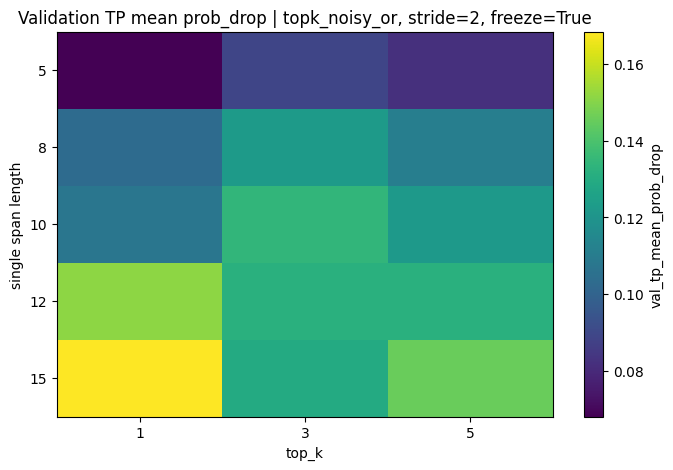

top_k,1,3,5
span_lengths_label,,,
5,0.068082,0.089237,0.082046
8,0.103123,0.122622,0.111178
10,0.107451,0.134138,0.122265
12,0.151238,0.131575,0.131780
15,0.168395,0.129415,0.145432


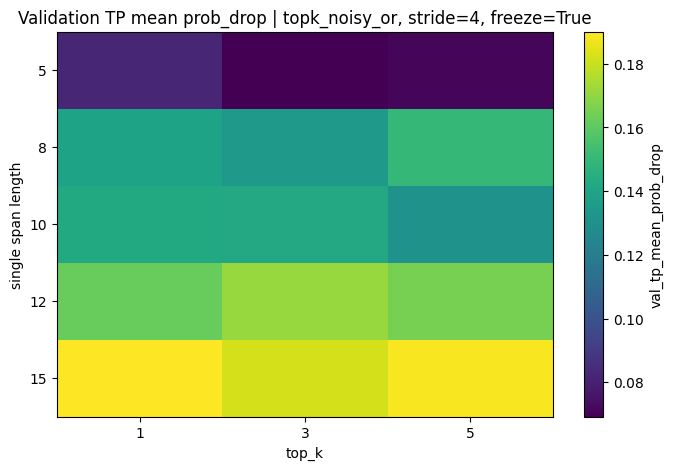

top_k,1,3,5
span_lengths_label,,,
5,0.082017,0.069206,0.071466
8,0.139286,0.133963,0.149944
10,0.142426,0.142314,0.131338
12,0.162058,0.171286,0.165472
15,0.190090,0.182525,0.189052


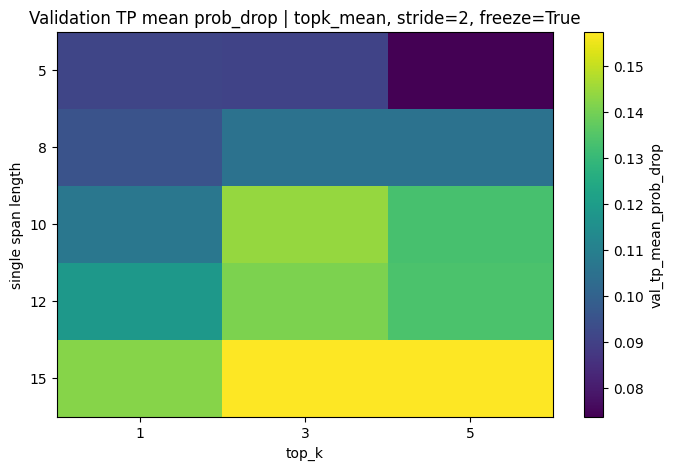

top_k,1,3,5
span_lengths_label,,,
5,0.091248,0.090427,0.073721
8,0.095063,0.105200,0.105159
10,0.106795,0.144038,0.133107
12,0.118348,0.140874,0.133541
15,0.142159,0.157369,0.157380


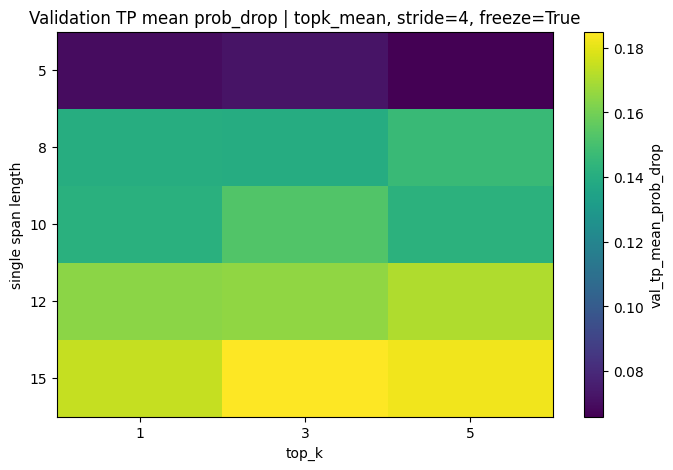

top_k,1,3,5
span_lengths_label,,,
5,0.069876,0.072044,0.065878
8,0.140100,0.139647,0.146482
10,0.141494,0.152513,0.142263
12,0.164335,0.165450,0.171035
15,0.174524,0.185002,0.182435


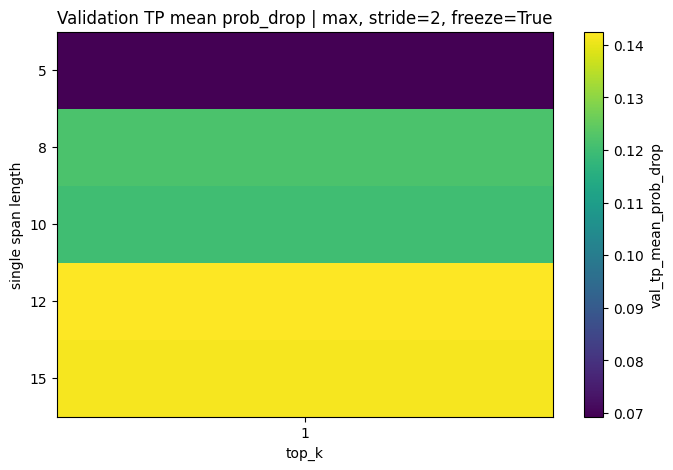

top_k,1
span_lengths_label,
5,0.069328
8,0.121761
10,0.119987
12,0.142477
15,0.141335


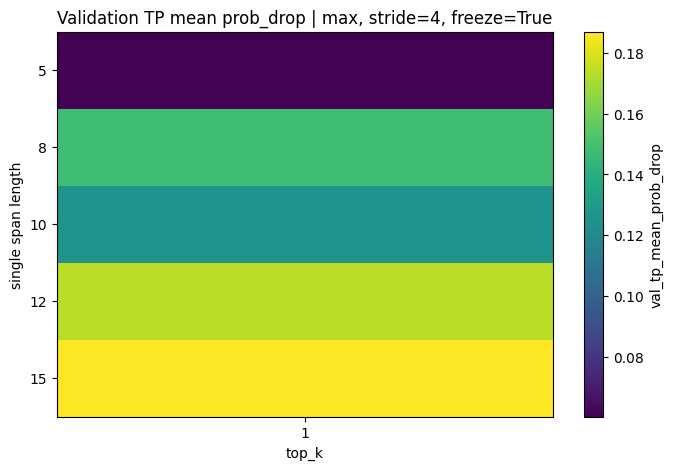

top_k,1
span_lengths_label,
5,0.060237
8,0.147548
10,0.126009
12,0.173775
15,0.187048


In [8]:
def plot_validation_heatmap(
    df,
    value_col,
    pooling_mode,
    stride,
    freeze_encoder,
    title,
    output_path,
):
    """Plot one validation heatmap for a fixed pooling/stride/freeze setting."""
    subset = df[
        (df["pooling_mode"] == pooling_mode) &
        (df["stride"] == stride) &
        (df["freeze_encoder"] == freeze_encoder)
    ].copy()
    
    if subset.empty:
        print("No data for", pooling_mode, stride, freeze_encoder)
        return
    
    heatmap_data = subset.pivot_table(
        index="span_lengths_label",
        columns="top_k",
        values=value_col,
        aggfunc="mean",
    )
    
    # Sort span lengths numerically, not lexicographically.
    heatmap_data = heatmap_data.reindex(
        sorted(
            heatmap_data.index,
            key=lambda x: int(str(x).split("-")[0])
        )
    )
    
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label=value_col)
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns,
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index,
    )
    
    plt.xlabel("top_k")
    plt.ylabel("single span length")
    plt.title(title)
    
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    display(heatmap_data)


plot_dir = OUTPUT_DIR / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

for pooling_mode in POOLING_MODES:
    for stride in STRIDE_VALUES:
        for freeze_encoder in FREEZE_ENCODER_VALUES:
            plot_validation_heatmap(
                df=val_config_summary,
                value_col="val_tp_mean_prob_drop",
                pooling_mode=pooling_mode,
                stride=stride,
                freeze_encoder=freeze_encoder,
                title=(
                    f"Validation TP mean prob_drop | "
                    f"{pooling_mode}, stride={stride}, freeze={freeze_encoder}"
                ),
                output_path=plot_dir / (
                    f"heatmap_prob_drop_{pooling_mode}_stride{stride}_freeze{freeze_encoder}.png"
                ),
            )

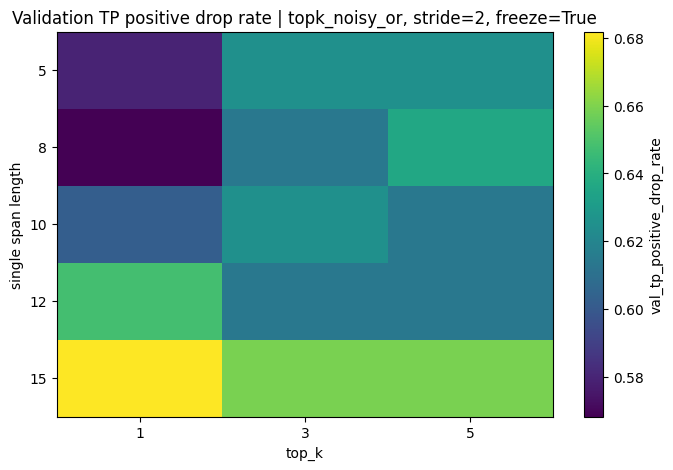

top_k,1,3,5
span_lengths_label,,,
5,0.579545,0.625000,0.625000
8,0.568182,0.613636,0.636364
10,0.602273,0.625000,0.613636
12,0.647727,0.613636,0.613636
15,0.681818,0.659091,0.659091


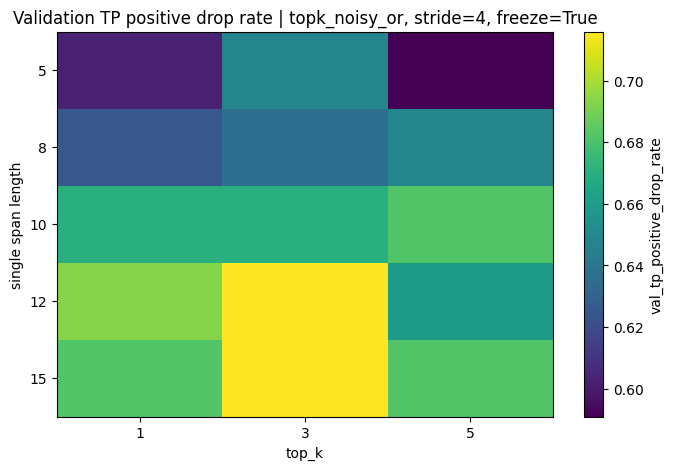

top_k,1,3,5
span_lengths_label,,,
5,0.602273,0.647727,0.590909
8,0.625000,0.636364,0.647727
10,0.670455,0.670455,0.681818
12,0.693182,0.715909,0.659091
15,0.681818,0.715909,0.681818


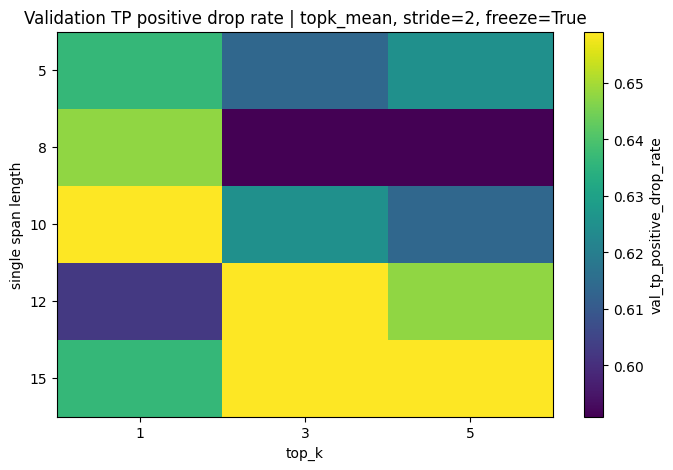

top_k,1,3,5
span_lengths_label,,,
5,0.636364,0.613636,0.625000
8,0.647727,0.590909,0.590909
10,0.659091,0.625000,0.613636
12,0.602273,0.659091,0.647727
15,0.636364,0.659091,0.659091


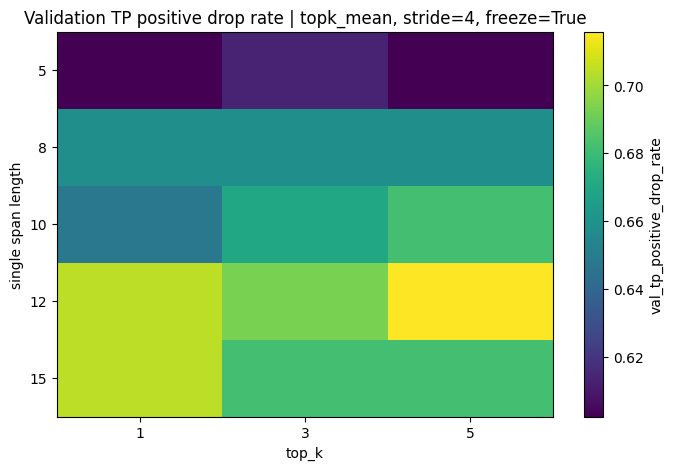

top_k,1,3,5
span_lengths_label,,,
5,0.602273,0.613636,0.602273
8,0.659091,0.659091,0.659091
10,0.647727,0.670455,0.681818
12,0.704545,0.693182,0.715909
15,0.704545,0.681818,0.681818


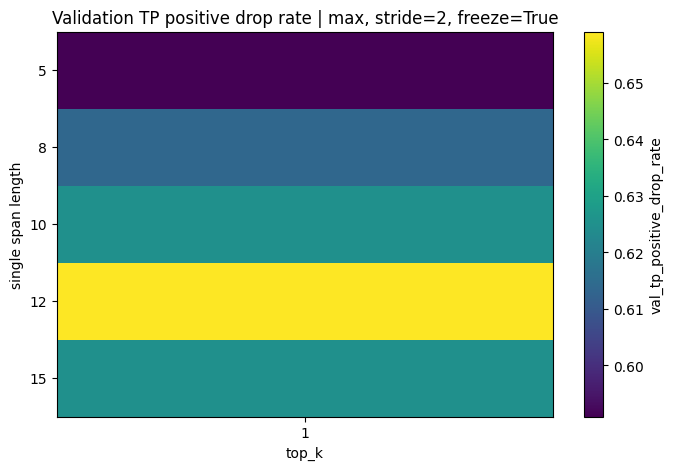

top_k,1
span_lengths_label,
5,0.590909
8,0.613636
10,0.625000
12,0.659091
15,0.625000


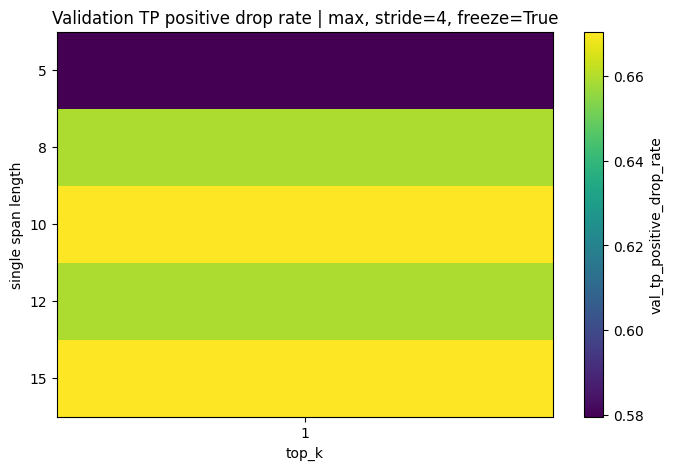

top_k,1
span_lengths_label,
5,0.579545
8,0.659091
10,0.670455
12,0.659091
15,0.670455


In [9]:
for pooling_mode in POOLING_MODES:
    for stride in STRIDE_VALUES:
        for freeze_encoder in FREEZE_ENCODER_VALUES:
            plot_validation_heatmap(
                df=val_config_summary,
                value_col="val_tp_positive_drop_rate",
                pooling_mode=pooling_mode,
                stride=stride,
                freeze_encoder=freeze_encoder,
                title=(
                    f"Validation TP positive drop rate | "
                    f"{pooling_mode}, stride={stride}, freeze={freeze_encoder}"
                ),
                output_path=plot_dir / (
                    f"heatmap_positive_drop_rate_{pooling_mode}_stride{stride}_freeze{freeze_encoder}.png"
                ),
            )

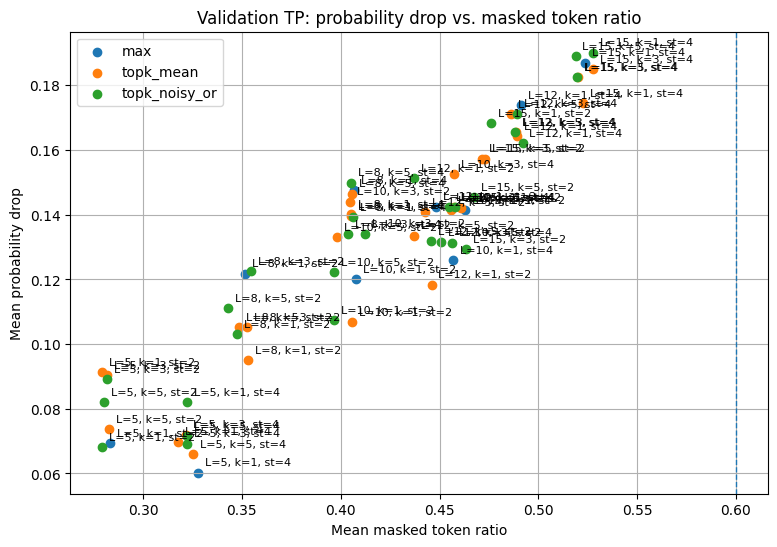

In [10]:
plt.figure(figsize=(9, 6))

for pooling_mode in sorted(val_config_summary["pooling_mode"].unique()):
    subset = val_config_summary[
        val_config_summary["pooling_mode"] == pooling_mode
    ].copy()
    
    plt.scatter(
        subset["val_tp_mean_masked_token_ratio"],
        subset["val_tp_mean_prob_drop"],
        label=pooling_mode,
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"L={row['span_lengths_label']}, k={row['top_k']}, st={row['stride']}",
            (
                row["val_tp_mean_masked_token_ratio"],
                row["val_tp_mean_prob_drop"],
            ),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

plt.axvline(
    x=SELECTED_MASK_BUDGET if SELECTED_MASK_BUDGET is not None else MAX_SELECTION_MASKED_TOKEN_RATIO,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop")
plt.title("Validation TP: probability drop vs. masked token ratio")
plt.grid(True)
plt.legend()

plot_path = plot_dir / "mil_validation_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

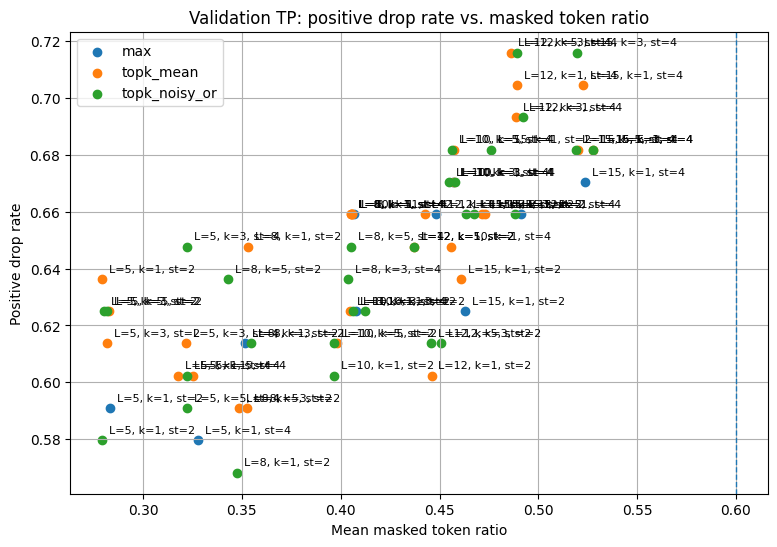

In [11]:
plt.figure(figsize=(9, 6))

for pooling_mode in sorted(val_config_summary["pooling_mode"].unique()):
    subset = val_config_summary[
        val_config_summary["pooling_mode"] == pooling_mode
    ].copy()
    
    plt.scatter(
        subset["val_tp_mean_masked_token_ratio"],
        subset["val_tp_positive_drop_rate"],
        label=pooling_mode,
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"L={row['span_lengths_label']}, k={row['top_k']}, st={row['stride']}",
            (
                row["val_tp_mean_masked_token_ratio"],
                row["val_tp_positive_drop_rate"],
            ),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

plt.axvline(
    x=SELECTED_MASK_BUDGET if SELECTED_MASK_BUDGET is not None else MAX_SELECTION_MASKED_TOKEN_RATIO,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Mean masked token ratio")
plt.ylabel("Positive drop rate")
plt.title("Validation TP: positive drop rate vs. masked token ratio")
plt.grid(True)
plt.legend()

plot_path = plot_dir / "mil_validation_positive_drop_rate_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

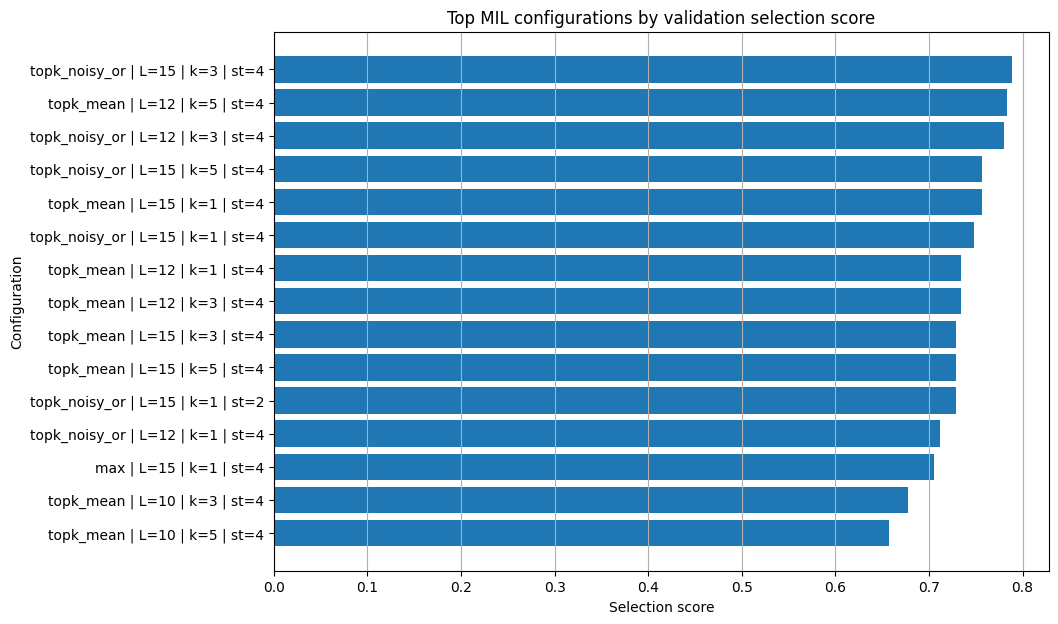

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/mil_results/mil_span_run_singles/plots/mil_validation_top_configs_selection_score.png


,short_label,selection_score,val_tp_mean_prob_drop,val_tp_positive_drop_rate,val_tp_mean_masked_token_ratio,val_tp_drop_per_masked_token_ratio,val_roc_auc,val_f1
28,topk_noisy_or | L=15 | k=3 | st=4,0.788571,0.182525,0.715909,0.519558,0.351308,0.767641,0.733624
53,topk_mean | L=12 | k=5 | st=4,0.782857,0.171035,0.715909,0.485990,0.351931,0.772513,0.720000
22,topk_noisy_or | L=12 | k=3 | st=4,0.780000,0.171286,0.715909,0.489308,0.350059,0.761341,0.673077
29,topk_noisy_or | L=15 | k=5 | st=4,0.757143,0.189052,0.681818,0.518821,0.364388,0.771547,0.735043
57,topk_mean | L=15 | k=1 | st=4,0.757143,0.174524,0.704545,0.522601,0.333953,0.755040,0.743590
27,topk_noisy_or | L=15 | k=1 | st=4,0.748571,0.190090,0.681818,0.527569,0.360313,0.758821,0.700000
51,topk_mean | L=12 | k=1 | st=4,0.734286,0.164335,0.704545,0.489332,0.335836,0.748236,0.746781
52,topk_mean | L=12 | k=3 | st=4,0.734286,0.165450,0.693182,0.488881,0.338426,0.764365,0.728070
58,topk_mean | L=15 | k=3 | st=4,0.728571,0.185002,0.681818,0.527688,0.350589,0.764953,0.726457
59,topk_mean | L=15 | k=5 | st=4,0.728571,0.182435,0.681818,0.520243,0.350673,0.774530,0.723214


In [12]:
top_ranked = candidate_configs.head(15).copy()

top_ranked["short_label"] = top_ranked.apply(
    lambda row: (
        f"{row['pooling_mode']} | "
        f"L={row['span_lengths_label']} | "
        f"k={row['top_k']} | "
        f"st={row['stride']}"
    ),
    axis=1,
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_ranked["short_label"][::-1],
    top_ranked["selection_score"][::-1],
)

plt.xlabel("Selection score")
plt.ylabel("Configuration")
plt.title("Top MIL configurations by validation selection score")
plt.grid(axis="x")

plot_path = plot_dir / "mil_validation_top_configs_selection_score.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

display(
    top_ranked[
        [
            "short_label",
            "selection_score",
            "val_tp_mean_prob_drop",
            "val_tp_positive_drop_rate",
            "val_tp_mean_masked_token_ratio",
            "val_tp_drop_per_masked_token_ratio",
            "val_roc_auc",
            "val_f1",
        ]
    ]
)

## Final selected MIL configuration

The final MIL configuration is selected on the validation split only.  
The test split is not used for hyperparameter selection.

The selection prioritizes perturbation behavior on validation true positives. In particular, it favors configurations with a high probability drop, a high positive drop rate, and a low masked token ratio. Bag-level metrics such as ROC-AUC are used only as weak guardrails to avoid selecting a collapsed MIL model.

The selected model is then applied to train, validation, and test to export comparable argument-level and span-level files.

In [ ]:
BEST_CONFIG_ID = BEST_CONFIG["config_id"]

best_config_clean = {
    "pooling_mode": BEST_CONFIG["pooling_mode"],
    "top_k": int(BEST_CONFIG["top_k"]),
    "span_lengths": tuple(int(x) for x in str(BEST_CONFIG["span_lengths_label"]).split("-")),
    "span_lengths_label": BEST_CONFIG["span_lengths_label"],
    "span_length_single": int(BEST_CONFIG["span_length_single"]) if "span_length_single" in BEST_CONFIG else int(str(BEST_CONFIG["span_lengths_label"]).split("-")[0]),
    "stride": int(BEST_CONFIG["stride"]),
    "freeze_encoder": bool(BEST_CONFIG["freeze_encoder"]),
    "config_id": BEST_CONFIG_ID,
}

print(best_config_clean, flush=True)

best_model = MILPoolingModel(
    model_name=MODEL_NAME,
    pooling_mode=best_config_clean["pooling_mode"],
    top_k=best_config_clean["top_k"],
    initial_instance_prob=INITIAL_INSTANCE_PROB,
    encoder_chunk_size=ENCODER_CHUNK_SIZE,
    encoder_dtype=ENCODER_DTYPE,
    freeze_encoder=best_config_clean["freeze_encoder"],
).to(TORCH_DEVICE)

best_model.load_state_dict(best_state_by_config[BEST_CONFIG_ID])
best_model.eval()

print("Loaded best validation model.", flush=True)

### Manually load specific or best model

In [17]:
BEST_CONFIG_ID = BEST_CONFIG["config_id"]

best_config_clean = {
    "pooling_mode": BEST_CONFIG["pooling_mode"],
    "top_k": int(BEST_CONFIG["top_k"]),
    "span_lengths": tuple(int(x) for x in str(BEST_CONFIG["span_lengths_label"]).split("-")),
    "span_lengths_label": BEST_CONFIG["span_lengths_label"],
    "span_length_single": int(BEST_CONFIG["span_length_single"]) if "span_length_single" in BEST_CONFIG else int(str(BEST_CONFIG["span_lengths_label"]).split("-")[0]),
    "stride": int(BEST_CONFIG["stride"]),
    "freeze_encoder": bool(BEST_CONFIG["freeze_encoder"]),
    "config_id": BEST_CONFIG_ID,
}

In [ ]:
# Load model from manually set checkpoint if necessary. This is useful for evaluation on test set without re-running the full validation grid.
DESIRED_CHECKPOINT_PATH = OUTPUT_DIR / "validation_grid/pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True/model_checkpoint.pt"
print("Using:", DESIRED_CHECKPOINT_PATH)

checkpoint = torch.load(
    DESIRED_CHECKPOINT_PATH,
    map_location="cpu",
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", checkpoint.keys())

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

In [15]:
# Load best_model if already exists
BEST_MODEL_PATH = OUTPUT_DIR / "mil_results_final/best_mil_model_checkpoint.pt"
print("Using:", BEST_MODEL_PATH)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu",
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", checkpoint.keys())

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

Using: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/mil_results/mil_span_run_singles/mil_results_final/best_mil_model_checkpoint.pt
Checkpoint type: <class 'dict'>
Checkpoint keys: dict_keys(['model_state_dict', 'best_config', 'validation_selection_row'])


In [ ]:
best_model = MILPoolingModel(
    model_name=MODEL_NAME,
    pooling_mode=best_config_clean["pooling_mode"],
    top_k=best_config_clean["top_k"],
    initial_instance_prob=INITIAL_INSTANCE_PROB,
    encoder_chunk_size=ENCODER_CHUNK_SIZE,
    encoder_dtype=ENCODER_DTYPE,
    freeze_encoder=best_config_clean["freeze_encoder"],
).to(TORCH_DEVICE)

best_model.load_state_dict(state_dict)
best_model.eval()

print("Loaded best validation model.", flush=True)

### Continue here after model is loaded

In [27]:
def build_dataset_for_best_config(df):
    """Build a MIL dataset for the selected final config."""
    return AppropriatenessMILDataset(
        df,
        span_lengths=best_config_clean["span_lengths"],
        stride=best_config_clean["stride"],
    )


train_best_dataset = build_dataset_for_best_config(train_df)
val_best_dataset = build_dataset_for_best_config(val_df)
test_best_dataset = build_dataset_for_best_config(test_df)

train_argument_df, train_span_df = collect_mil_outputs(
    model=best_model,
    dataset=train_best_dataset,
    config=best_config_clean,
)

val_argument_df, val_span_df = collect_mil_outputs(
    model=best_model,
    dataset=val_best_dataset,
    config=best_config_clean,
)

test_argument_df, test_span_df = collect_mil_outputs(
    model=best_model,
    dataset=test_best_dataset,
    config=best_config_clean,
)

print(train_argument_df.shape, train_span_df.shape)
print(val_argument_df.shape, val_span_df.shape)
print(test_argument_df.shape, test_span_df.shape)

(1533, 27) (29666, 28)
(220, 27) (4353, 28)
(438, 27) (8523, 28)


In [28]:
train_argument_df, train_top_span_df = add_mil_perturbation_scores(
    train_argument_df,
    train_span_df,
    top_n_spans=MASKING_TOP_N_SPANS,
)

val_argument_df, val_top_span_df = add_mil_perturbation_scores(
    val_argument_df,
    val_span_df,
    top_n_spans=MASKING_TOP_N_SPANS,
)

test_argument_df, test_top_span_df = add_mil_perturbation_scores(
    test_argument_df,
    test_span_df,
    top_n_spans=MASKING_TOP_N_SPANS,
)

final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True,
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True,
)

final_top_span_df = pd.concat(
    [train_top_span_df, val_top_span_df, test_top_span_df],
    ignore_index=True,
)

display(final_argument_df.head())
display(final_span_df.head())
display(final_top_span_df.head())

Classifier inference:   0%|          | 0/48 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/7 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/14 [00:00<?, ?it/s]

,global_row_id,post_id,split,issue,text,label,p_inappropriate_original,predicted_label_original,predicted_score_original,confusion_type,...,selected_span_texts,selected_span_char_start_indices,selected_span_char_end_indices,selected_span_word_start_indices,selected_span_word_end_indices,n_selected_spans,total_masked_chars,total_masked_words,n_words,masked_word_ratio
0,0,1,train,Is the school uniform a good or bad idea:,"people cant be forced to wear school uniforms,...",1,0.997032,LABEL_1,0.997032,TP,...,"[i mean each person has theri own wish, whethe...","[47, 85, 66]","[84, 121, 105]","[8, 16, 12]","[15, 23, 19]",3,112,24,38,0.631579
1,1,2,train,Firefox vs internet explorer:,"That form of argument degrades this forum, and...",1,0.998218,LABEL_1,0.998218,TP,...,"[your style of debate. Check them out., lowest...","[325, 87, 0]","[362, 145, 46]","[56, 16, 0]","[62, 23, 7]",3,141,23,63,0.365079
2,2,3,train,If your spouse committed murder and he or she ...,I wouldnt turn her in becuase she is my wife. ...,0,0.030317,LABEL_0,0.969683,TN,...,"[by telling me what she did then I, If she tru...","[108, 90, 73]","[141, 126, 107]","[24, 20, 16]","[31, 27, 23]",3,103,24,37,0.648649
3,3,4,train,If your spouse committed murder and he or she ...,No I wouldn't turn in my spouse. Just because ...,1,0.998705,LABEL_1,0.998705,TP,...,"[in my spouse. Just because the girl that, bec...","[19, 38, 105]","[59, 84, 143]","[4, 8, 20]","[11, 15, 24]",3,124,21,25,0.840000
4,4,5,train,Tv is better than books:,TV is terrible. Except for Spongebob maybe. Th...,1,0.998405,LABEL_1,0.998405,TP,...,[TV is terrible. Except for Spongebob maybe. T...,"[0, 23, 119]","[50, 74, 151]","[0, 4, 20]","[7, 11, 26]",3,133,23,27,0.851852


,global_row_id,post_id,split,issue,label,confusion_type,mil_probability,mil_predicted_label,span_score,span_logit,...,text,pooling_mode,top_k,span_lengths,span_lengths_label,span_length_single,stride,freeze_encoder,config_id,span_rank
0,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.029178,0,0.000015,-11.079542,...,"people cant be forced to wear school uniforms,...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,8
1,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.029178,0,0.004611,-5.374704,...,"people cant be forced to wear school uniforms,...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,4
2,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.029178,0,0.011916,-4.417877,...,"people cant be forced to wear school uniforms,...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,1
3,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.029178,0,0.005464,-5.204016,...,"people cant be forced to wear school uniforms,...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,3
4,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.029178,0,0.007437,-4.893886,...,"people cant be forced to wear school uniforms,...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,2


,global_row_id,post_id,split,issue,label,confusion_type,mil_probability,mil_predicted_label,span_score,span_logit,...,text,pooling_mode,top_k,span_lengths,span_lengths_label,span_length_single,stride,freeze_encoder,config_id,span_rank
0,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.029178,0,0.011916,-4.417877,...,"people cant be forced to wear school uniforms,...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,1
1,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.029178,0,0.007437,-4.893886,...,"people cant be forced to wear school uniforms,...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,2
2,0,1,train,Is the school uniform a good or bad idea:,1,TP,0.029178,0,0.005464,-5.204016,...,"people cant be forced to wear school uniforms,...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,3
3,1,2,train,Firefox vs internet explorer:,1,TP,0.990913,1,0.768173,1.198025,...,"That form of argument degrades this forum, and...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,1
4,1,2,train,Firefox vs internet explorer:,1,TP,0.990913,1,0.744196,1.067894,...,"That form of argument degrades this forum, and...",topk_noisy_or,5,"(8,)",8,8,4,True,pool=topk_noisy_or__topk=5__spans=8__stride=4_...,2


In [ ]:
overall_summary = (
    final_argument_df
    .groupby([
        "split",
        "attribution_method",
        "pooling_mode",
        "top_k",
        "span_lengths_label",
        "stride",
        "freeze_encoder",
    ])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_mil_probability=("mil_probability", "mean"),
        std_mil_probability=("mil_probability", "std"),
        mean_n_selected_spans=("n_selected_spans", "mean"),
        mean_total_masked_words=("total_masked_words", "mean"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_masked_word_ratio=("masked_word_ratio", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_n_model_tokens=("n_model_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

overall_summary["drop_per_masked_token_ratio"] = (
    overall_summary["mean_prob_drop"] /
    overall_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

confusion_summary = (
    final_argument_df
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_mil_probability=("mil_probability", "mean"),
        mean_total_masked_words=("total_masked_words", "mean"),
        mean_masked_word_ratio=("masked_word_ratio", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_n_model_tokens=("n_model_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

confusion_summary["drop_per_masked_ratio"] = (
    confusion_summary["mean_prob_drop"] /
    confusion_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

test_summary = overall_summary[
    overall_summary["split"] == "test"
].copy()

display(overall_summary)
display(confusion_summary)
display(test_summary)

,split,attribution_method,pooling_mode,top_k,span_lengths_label,stride,freeze_encoder,n_arguments,mean_prob_drop,median_prob_drop,...,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_mil_probability,std_mil_probability,mean_n_selected_spans,mean_total_masked_words,mean_total_masked_chars,mean_masked_word_ratio,drop_per_masked_ratio
0,test,mil,topk_noisy_or,5,8,4,True,438,-0.004440,0.000018,...,0.143836,0.590804,0.595245,0.477978,0.428550,2.986301,23.461187,125.910959,0.453766,-0.009786
1,train,mil,topk_noisy_or,5,8,4,True,1533,-0.045487,-0.000025,...,0.110241,0.552141,0.597628,0.477798,0.424543,2.985649,23.491194,127.058708,0.456056,-0.099740
2,validation,mil,topk_noisy_or,5,8,4,True,220,-0.000749,0.000045,...,0.154545,0.542075,0.542823,0.453427,0.423558,2.981818,23.363636,125.613636,0.444014,-0.001686


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_mil_probability,mean_total_masked_words,mean_masked_word_ratio,drop_per_masked_ratio
0,test,FN,39,-0.188091,-0.009908,0.370980,0.333333,0.153846,0.102564,0.049638,0.237729,0.404421,23.641026,0.372759,-0.504591
1,test,FP,71,0.119460,0.000201,0.297125,0.591549,0.253521,0.197183,0.971585,0.852125,0.446612,23.408451,0.530219,0.225304
2,test,TN,142,-0.155035,-0.002749,0.329614,0.352113,0.119718,0.063380,0.037216,0.192251,0.236411,23.690141,0.315399,-0.491551
3,test,TP,186,0.101741,0.000184,0.263263,0.623656,0.236559,0.193548,0.981555,0.879813,0.689797,23.268817,0.547204,0.185930
4,train,FN,48,-0.244633,-0.026087,0.396971,0.333333,0.291667,0.187500,0.115297,0.359930,0.311897,23.500000,0.442543,-0.552790
5,train,FP,48,0.126972,-0.000280,0.369169,0.437500,0.291667,0.270833,0.915789,0.788817,0.301694,23.520833,0.558443,0.227368
6,train,TN,652,-0.200081,-0.003412,0.359511,0.326687,0.096626,0.033742,0.030158,0.230240,0.222302,23.680982,0.377674,-0.529773
7,train,TP,785,0.084546,0.000212,0.234378,0.634395,0.205096,0.159236,0.990161,0.905615,0.710919,23.331210,0.515723,0.163938
8,validation,FN,36,-0.170912,-0.006610,0.342840,0.277778,0.166667,0.083333,0.040581,0.211493,0.428224,23.583333,0.366964,-0.465747
9,validation,FP,30,0.190517,0.000717,0.341128,0.733333,0.366667,0.300000,0.968823,0.778306,0.329047,23.233333,0.518566,0.367392


,split,attribution_method,pooling_mode,top_k,span_lengths_label,stride,freeze_encoder,n_arguments,mean_prob_drop,median_prob_drop,...,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_mil_probability,std_mil_probability,mean_n_selected_spans,mean_total_masked_words,mean_total_masked_chars,mean_masked_word_ratio,drop_per_masked_ratio
0,test,mil,topk_noisy_or,5,8,4,True,438,-0.00444,0.000018,...,0.143836,0.590804,0.595245,0.477978,0.42855,2.986301,23.461187,125.910959,0.453766,-0.009786


In [ ]:
test_tp_summary = (
    final_argument_df[
        (final_argument_df["split"] == "test") &
        (final_argument_df["confusion_type"] == "TP")
    ]
    .groupby([
        "split",
        "confusion_type",
        "attribution_method",
        "pooling_mode",
        "top_k",
        "span_lengths_label",
        "stride",
        "freeze_encoder",
    ])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_masked_word_ratio=("masked_word_ratio", "mean"),
        mean_total_masked_words=("total_masked_words", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_n_model_tokens=("n_model_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

test_tp_summary["drop_per_masked_ratio"] = (
    test_tp_summary["mean_prob_drop"] /
    test_tp_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

display(test_tp_summary)

,split,confusion_type,attribution_method,pooling_mode,top_k,span_lengths_label,stride,freeze_encoder,n_arguments,mean_prob_drop,median_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_masked_word_ratio,mean_total_masked_words,drop_per_masked_ratio
0,test,TP,mil,topk_noisy_or,5,8,4,True,186,0.101741,0.000184,0.623656,0.236559,0.193548,0.547204,23.268817,0.18593


In [31]:
final_output_dir = OUTPUT_DIR / "mil_results_final"
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_span_level.csv"
)

top_span_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_top_spans.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"mil_final_all_splits"
    f"_{BEST_CONFIG_ID}"
    f"_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"mil_final_test"
    f"_{BEST_CONFIG_ID}"
    f"_summary.csv"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
final_top_span_df.to_csv(top_span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

with open(final_output_dir / "best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config_clean, f, indent=2, ensure_ascii=False)

torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "best_config": best_config_clean,
        "validation_selection_row": BEST_CONFIG,
    },
    final_output_dir / "best_mil_model_checkpoint.pt",
)

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(top_span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)

Saved:
mil_results_new/mil_span_run_20260802_114055/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=5__spans=8__stride=4__freeze=True_argument_level.csv
mil_results_new/mil_span_run_20260802_114055/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=5__spans=8__stride=4__freeze=True_span_level.csv
mil_results_new/mil_span_run_20260802_114055/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=5__spans=8__stride=4__freeze=True_top_spans.csv
mil_results_new/mil_span_run_20260802_114055/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=5__spans=8__stride=4__freeze=True_overall_summary.csv
mil_results_new/mil_span_run_20260802_114055/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=5__spans=8__stride=4__freeze=True_confusion_summary.csv
mil_results_new/mil_span_run_20260802_114055/mil_results_final/mil_final_test_pool=topk_noisy_or__topk=5__spans=8__stride=4__freeze=True_summary.csv


In [ ]:
def show_mil_example(result_df, index=0):
    """Display one MIL result with highlighted selected spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["selected_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>classifier confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>MIL confusion_type:</b> {html.escape(str(row["mil_confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>pooling:</b> {html.escape(str(row["pooling_mode"]))} |
        <b>top_k:</b> {html.escape(str(row["top_k"]))} |
        <b>span_lengths:</b> {html.escape(str(row["span_lengths_label"]))} |
        <b>stride:</b> {html.escape(str(row["stride"]))} |
        <b>freeze_encoder:</b> {html.escape(str(row["freeze_encoder"]))}<br>
        <b>selected spans:</b> {html.escape(str(row["selected_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>MIL probability:</b> {float(row["mil_probability"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

In [ ]:
test_valid = test_argument_df.copy()

best_examples = (
    test_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

print("Best MIL perturbation examples:")
display(
    best_examples[
        [
            "global_row_id",
            "post_id",
            "confusion_type",
            "mil_confusion_type",
            "prob_drop",
            "masked_token_ratio",
            "selected_span_texts",
        ]
    ].head(10)
)

for i in range(min(5, len(best_examples))):
    show_mil_example(best_examples, index=i)

Best MIL perturbation examples:


,global_row_id,post_id,confusion_type,mil_confusion_type,prob_drop,masked_word_ratio,selected_span_texts
0,1769,71,FP,FP,0.992228,0.400000,"[homosexuality all together, and therefore the..."
1,1835,407,FP,FP,0.990775,0.363636,"[to abide by it? And... the answer is, KNOWING..."
2,2075,1609,TP,TP,0.989959,0.365079,"[should not mix. That solves the ""problem""., T..."
3,2034,1349,TP,FN,0.974209,0.174603,[You have all missed the point. Confidential s...
4,2148,1966,FP,TN,0.973864,0.307692,"[not rape, then there would be nothing to, All..."
5,2090,1667,TP,FN,0.971134,0.198347,"[seen as suspicious, these women relly need to..."
6,1851,475,TP,TP,0.965389,0.264368,[of Firefox... Weakness. For every feature the...
7,1976,1077,TP,TP,0.956035,0.179104,[being blown off. That why I cannot comprehend...
8,2022,1289,FP,FP,0.923792,0.252632,"[like about 1 hr just to find their, don't hav..."
9,2015,1268,TP,TP,0.836114,0.666667,"[to and from school. now there are child, from..."


In [ ]:
worst_examples = (
    test_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

print("Lowest or negative MIL perturbation examples:")
display(
    worst_examples[
        [
            "global_row_id",
            "post_id",
            "confusion_type",
            "mil_confusion_type",
            "prob_drop",
            "masked_token_ratio",
            "selected_span_texts",
        ]
    ].head(10)
)

for i in range(min(5, len(worst_examples))):
    show_mil_example(worst_examples, index=i)

Lowest or negative MIL perturbation examples:


,global_row_id,post_id,confusion_type,mil_confusion_type,prob_drop,masked_word_ratio,selected_span_texts
0,1842,434,TN,FP,-0.993850,0.196721,"[""You're privileged, so your opinion on this i..."
1,1766,63,TN,TN,-0.993702,0.666667,"[in because i don't think that's right, killin..."
2,2175,2096,TN,TN,-0.991867,0.666667,"[solve problems, for example using the other t..."
3,1920,789,TN,TN,-0.990082,0.418182,"[If my wife confided in me than I, she just th..."
4,1947,950,TN,TN,-0.988586,0.705882,"[If my wife was to commit murder and, told me ..."
5,2081,1621,TN,TN,-0.987005,1.000000,"[It's ok for the parent to spank the, it's not..."
6,1929,859,TN,TN,-0.986033,0.648649,[Personal pursuit is better in my opinion. How...
7,2151,1978,TN,TN,-0.984063,0.190476,"[I think it's really two different questions, ..."
8,2144,1939,FN,FN,-0.981082,0.923077,"[last up to 2 or 3 weeks or, minute, but punis..."
9,1896,696,FN,FN,-0.976424,0.436364,"[them, same thing with girls, give them games,..."


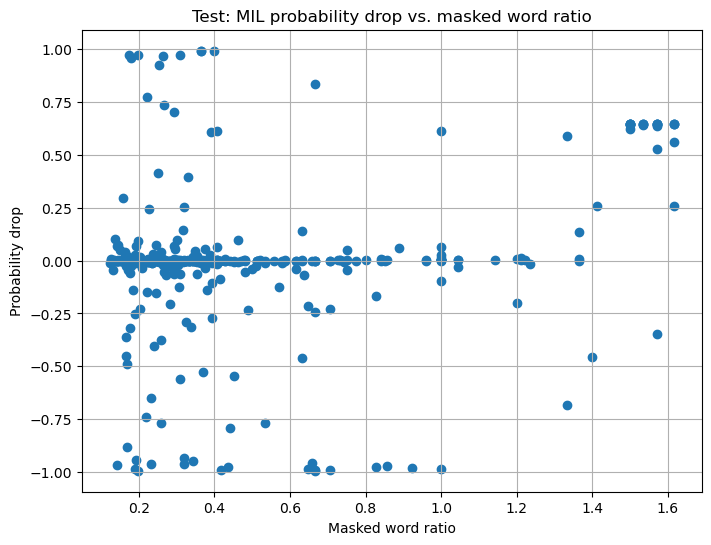

Saved plot: mil_results_new/mil_span_run_20260802_114055/plots/mil_test_prob_drop_vs_masked_word_ratio.png


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    test_argument_df["masked_token_ratio"],
    test_argument_df["prob_drop"],
)

plt.xlabel("Masked token ratio")
plt.ylabel("Probability drop")
plt.title("Test: MIL probability drop vs. masked token ratio")
plt.grid(True)

plot_path = plot_dir / "mil_test_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

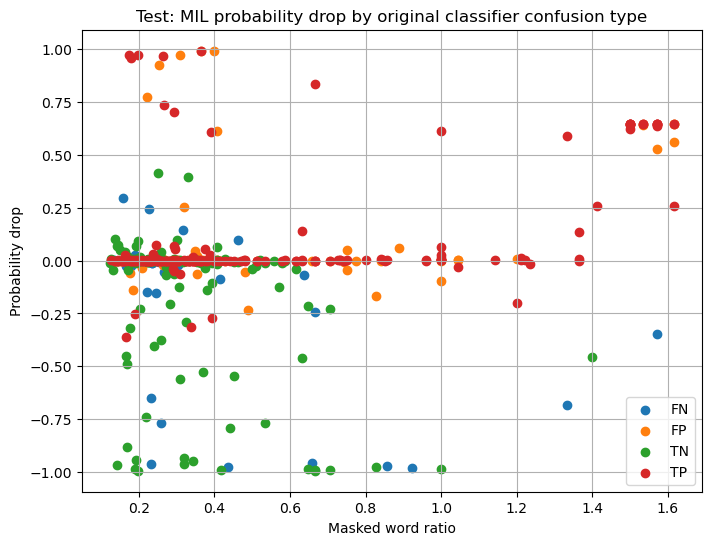

Saved plot: mil_results_new/mil_span_run_20260802_114055/plots/mil_test_prob_drop_by_confusion_type.png


In [ ]:
plt.figure(figsize=(8, 6))

for confusion_type in sorted(test_argument_df["confusion_type"].unique()):
    subset = test_argument_df[
        test_argument_df["confusion_type"] == confusion_type
    ]
    
    plt.scatter(
        subset["masked_token_ratio"],
        subset["prob_drop"],
        label=confusion_type,
    )

plt.xlabel("Masked token ratio")
plt.ylabel("Probability drop")
plt.title("Test: MIL probability drop by original classifier confusion type")
plt.grid(True)
plt.legend()

plot_path = plot_dir / "mil_test_prob_drop_by_confusion_type.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

## Interpretation

The MIL bag-level metrics evaluate whether the trained MIL model can reproduce the document-level inappropriateness labels. They do not directly validate the correctness of the extracted spans because no gold span-level annotations are available.

The perturbation evaluation provides a proxy for span relevance. If masking the top-ranked MIL spans reduces the inappropriate probability of the original Ziegenbein classifier, this indicates that the selected spans capture information relevant to the document-level classifier.

Therefore, the final evaluation consists of two complementary parts:

1. **Bag-level classification quality**  
   Evaluates whether the MIL model learns a useful document-level decision function.

2. **Perturbation-based span evaluation**  
   Evaluates whether the selected MIL spans affect the original document-level classifier when removed or masked.